# Age and Gender Detection

This project implements a deep learning pipeline for detecting faces in images or videos and predicting the age and gender of each detected face using pre-trained models from OpenCV. It supports processing static images, webcam streams, and video files.


## Algorithm Explanation


The process for age and gender detection follows these steps:

### 1. **Face Detection**
- A pretrained face detection model (based on ResNet) is used.
- The image is converted into a blob and passed to `faceNet` for inference.
- Bounding boxes are drawn around detected faces with confidence above a defined threshold.

### 2. **Face Cropping with Padding**
- Each face bounding box is expanded using padding.
- The face region is cropped for further analysis.

### 3. **Blob Conversion**
- The cropped face is converted into a blob (227×227) using pre-defined mean subtraction values for normalization.

### 4. **Age and Gender Prediction**
- The blob is fed into `ageNet` and `genderNet`:
  - `genderNet` predicts male or female.
  - `ageNet` classifies the face into one of 8 age groups.

### 5. **Display and Overlay**
- The predicted age and gender are displayed above the bounding box using OpenCV’s drawing functions.


# Requirements
Make sure you have the following Python packages installed:


In [1]:
# Importing Requirements
import cv2
import time
import numpy as np
import os
import matplotlib.pyplot as plt

# Required Files and Model Downloads

Ensure the following files are placed inside the `configs/` directory:

| File                          | Purpose                  |
|-------------------------------|--------------------------|
| opencv_face_detector.pbtxt    | Face detection config   |
| opencv_face_detector_uint8.pb | Face detection model    |
| age_deploy.prototxt           | Age model config        |
| age_net.caffemodel            | Age model weights       |
| gender_deploy.prototxt        | Gender model config     |
| gender_net.caffemodel         | Gender model weights    |

# How to Run the Project

- Download the required Caffe models and prototxt files (linked in your course GitHub or OpenCV documentation).

- Place model files inside the configs/ directory.

- Place test images inside the images/ directory.

- Place video files inside the videos/ directory.

- Run the notebook to:

  - Test on individual images

  - Use webcam for live testing

  - Evaluate videos frame-by-frame

# Load Models

In [2]:
# File paths to the pre-trained models and configuration files.

faceProto   = os.path.join("configs", "opencv_face_detector.pbtxt")
faceModel   = os.path.join("configs", "opencv_face_detector_uint8.pb")
ageProto    = os.path.join("configs", "age_deploy.prototxt")
ageModel    = os.path.join("configs", "age_net.caffemodel")
genderProto = os.path.join("configs", "gender_deploy.prototxt")
genderModel = os.path.join("configs", "gender_net.caffemodel")

# Mean values used for mean subtraction in preprocessing.
MODEL_MEAN_VALUES = (78.4263377603, 87.7689143744, 114.895847746)
ageList = ["(0-2)", "(4-6)", "(8-12)", "(15-20)", "(25-32)", 
           "(38-43)", "(48-53)", "(60-100)"]
genderList = ["Male", "Female"]

faceNet = cv2.dnn.readNet(faceModel, faceProto)
ageNet = cv2.dnn.readNet(ageModel, ageProto)
genderNet = cv2.dnn.readNet(genderModel, genderProto)

# Camera Test

In [3]:
def visualize_fps(image, fps: int):
    # Check if the image is grayscale or colored.
    # If it's grayscale, set text color to white; if colored, set text color to green.
    if len(np.shape(image)) < 3:
        text_color = (255, 255, 255)  # White color for grayscale images.
    else:
        text_color = (0, 255, 0)  # Green color for colored images.

    # Define the row size for the text placement.
    row_size = 20 
    # Define the left margin for the text placement.
    left_margin = 24 

    # Set the font size and thickness for the text.
    font_size = 1
    font_thickness = 2

    # Format the FPS value into a string for displaying.
    fps_text = "FPS = {:.1f}".format(fps)
    # Set the text location on the image.
    text_location = (left_margin, row_size)
    
    # Place the FPS text on the image.
    cv2.putText(
        image,
        fps_text,
        text_location,
        cv2.FONT_HERSHEY_PLAIN,
        font_size,
        text_color,
        font_thickness,
    )

    # Return the modified image with the FPS text.
    return image


In [4]:
# Constants for camera settings
CAMERA_DEVICE_ID = 0  # ID for the camera device
IMAGE_WIDTH = 800  # Width of the captured image
IMAGE_HEIGHT = 600  # Height of the captured image
fps = 0  # Initial Frames Per Second (FPS) value

if __name__ == "__main__":  # Ensures that the code only runs when executed directly
    try:
        cap = cv2.VideoCapture(CAMERA_DEVICE_ID)  # Initialize video capture with the specified camera device ID
        while True:  # Infinite loop to continuously capture frames
            start_time = time.time()  # Record the start time to calculate FPS
            _, frame = cap.read()  # Capture a single frame from the camera
            frame = cv2.resize(frame, (IMAGE_WIDTH, IMAGE_HEIGHT))  # Resize the frame to the specified dimensions
            # Display the frame with FPS overlay
            cv2.imshow("frame", visualize_fps(frame, fps)) 
            end_time = time.time()  # Record the end time to calculate FPS
            # Calculate the time taken to process the frame
            seconds = end_time - start_time 
            # Calculate FPS based on the time taken to process the frame
            fps = 1.0 / seconds
            # Break the loop if the 'Esc' key (ASCII 27) is pressed
            if cv2.waitKey(33) == 27:  
                break
    except Exception as e:  # Handle exceptions that may occur
        print(e)  # Print the exception message
    finally:
        cv2.destroyAllWindows()  # Close all OpenCV windows
        cap.release()  # Release the camera resource


OpenCV(4.10.0) C:\b\abs_a3k2mim6t7\croot\opencv-suite_1744821726920\work\modules\imgproc\src\resize.cpp:4152: error: (-215:Assertion failed) !ssize.empty() in function 'cv::resize'



# Loading Video

In [5]:
# Constants for video settings
# Define the path to the video file using os.path.join
CAMERA_DEVICE_ID = os.path.join("videos", "Einstein_2.mp4")  # Path to the video file
IMAGE_WIDTH = 1000  # Width of the displayed image
IMAGE_HEIGHT = 600  # Height of the displayed image
fps = 0  # Initial Frames Per Second (FPS) value
FRAME_RATE = 30  # Desired frame rate
DURATION = 1 / FRAME_RATE  # Duration of each frame

if __name__ == "__main__":  # Ensures that the code only runs when executed directly
    try:
        cap = cv2.VideoCapture(CAMERA_DEVICE_ID)  # Initialize video capture with the specified video file path

        while True:  # Infinite loop to continuously capture frames
            start_time = time.time()  # Record the start time to calculate FPS

            _, frame = cap.read()  # Capture a single frame from the video
            frame = cv2.resize(frame, (IMAGE_WIDTH, IMAGE_HEIGHT))  # Resize the frame to the specified dimensions

            end_time = time.time()  # Record the end time to calculate FPS

            # Calculate the time taken to process the frame
            seconds = end_time - start_time

            # If the processing time is less than the desired frame duration, wait for the remaining time
            if seconds < DURATION:
                time.sleep(DURATION - seconds)

            # Recalculate the time taken to process the frame including sleep time
            seconds = time.time() - start_time
            # Calculate FPS based on the time taken to process the frame
            fps = 1.0 / seconds

            # Display the frame with FPS overlay
            cv2.imshow("frame", visualize_fps(frame, fps))

            # Break the loop if the 'Esc' key (ASCII 27) is pressed
            if cv2.waitKey(33) == 27:  
                break
    except Exception as e:  # Handle exceptions that may occur
        print(e)  # Print the exception message
    finally:
        cv2.destroyAllWindows()  # Close all OpenCV windows
        cap.release()  # Release the video capture resource


# Detect Age and Gender in a Frame

In [6]:
def highlightFace(net, frame, conf_threshold=0.7):
    frameOpencvDNN = frame.copy()
    frameHeight = frameOpencvDNN.shape[0]
    frameWidth = frameOpencvDNN.shape[1]
    blob = cv2.dnn.blobFromImage(frameOpencvDNN, 1.0, (300, 300), [104, 117, 123], True, False)
    net.setInput(blob)
    detections = net.forward()
    faceBoxes = []
    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        if confidence > conf_threshold:
            x1 = int(detections[0, 0, i, 3] * frameWidth)
            y1 = int(detections[0, 0, i, 4] * frameHeight)
            x2 = int(detections[0, 0, i, 5] * frameWidth)
            y2 = int(detections[0, 0, i, 6] * frameHeight)
            faceBoxes.append([x1, y1, x2, y2])
            cv2.rectangle(frameOpencvDNN, (x1, y1), (x2, y2), (0, 255, 0), int(round(frameHeight / 150)), 8)
    return frameOpencvDNN, faceBoxes

In [7]:
def detect_face_age_gender(frame, padding=20):
    resultImg, faceBoxes = highlightFace(faceNet, frame)
    if not faceBoxes:  # Check if any faces were detected
        print("No face detected")
        return frame
    # Iterate over the detected face bounding boxes
    face = None
    for faceBox in faceBoxes:
        face = frame[max(0, faceBox[1] - padding) : min(faceBox[3] + padding, frame.shape[0] - 1),
                     max(0, faceBox[0] - padding) : min(faceBox[2] + padding, frame.shape[1] - 1)]
    if face is None:
        return
    blob = cv2.dnn.blobFromImage(face, 1.0, (227, 227), MODEL_MEAN_VALUES, swapRB=False)
    # Predict gender using the gender detection model
    genderNet.setInput(blob)
    genderPreds = genderNet.forward()
    gender = genderList[genderPreds[0].argmax()]
    # Predict age using the age detection model
    ageNet.setInput(blob)
    agePreds = ageNet.forward()
    age = ageList[agePreds[0].argmax()]
    # Overlay the gender and age prediction on the image
    text = f"{gender}, {age}"
    x1, y1, x2, y2 = faceBox
    cv2.putText(resultImg, text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2, cv2.LINE_AA)
    cv2.rectangle(resultImg, (x1, y1), (x2, y2), (0, 255, 0), 2) 
    return resultImg

In [8]:
# === Setup ===
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Age and Gender Detection on Image

Multiple images are processed and visualized to verify the model's predictions. The model overlays the age and gender prediction above each face.

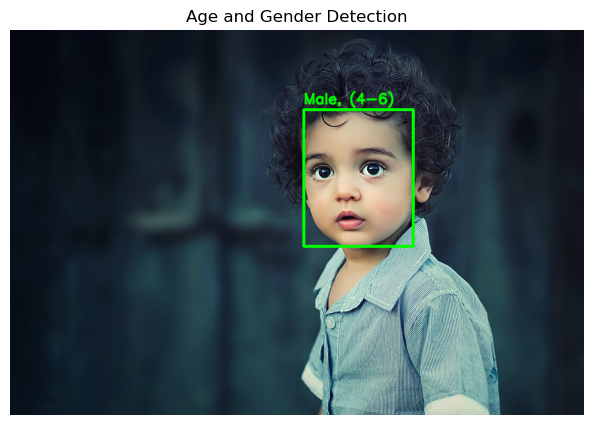

Saved static image result to output\kid_detected.jpg


In [9]:
# === Static Image Test ===
IMAGE_ADDRESS = os.path.join("images", "kid.jpg")
image = cv2.imread(IMAGE_ADDRESS)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
result = detect_face_age_gender(image)

plt.figure(figsize=(10, 5))
plt.imshow(result)
plt.axis("off")
plt.title("Age and Gender Detection")
plt.show()

# Save the result to output directory
result_bgr = cv2.cvtColor(result, cv2.COLOR_RGB2BGR)
output_image_path = os.path.join(OUTPUT_DIR, "kid_detected.jpg")
cv2.imwrite(output_image_path, result_bgr)
print(f"Saved static image result to {output_image_path}")

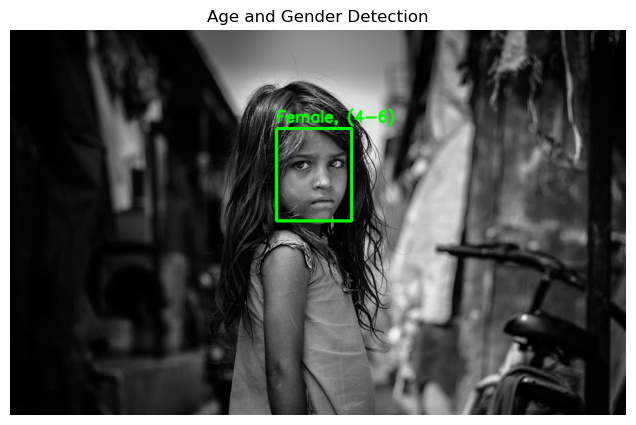

Saved static image result to output\girl_detected.jpg


In [10]:
# === Static Image Test ===
IMAGE_ADDRESS = os.path.join("images", "girl.jpg")
image = cv2.imread(IMAGE_ADDRESS)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
result = detect_face_age_gender(image)

plt.figure(figsize=(10, 5))
plt.imshow(result)
plt.axis("off")
plt.title("Age and Gender Detection")
plt.show()

# Save the result to output directory
result_bgr = cv2.cvtColor(result, cv2.COLOR_RGB2BGR)
output_image_path = os.path.join(OUTPUT_DIR, "girl_detected.jpg")
cv2.imwrite(output_image_path, result_bgr)
print(f"Saved static image result to {output_image_path}")

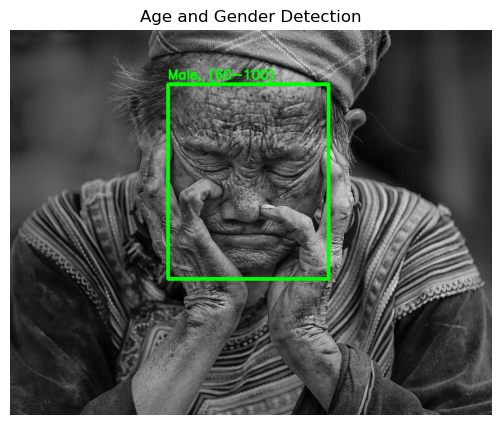

Saved static image result to output\man_detected.jpg


In [11]:
# === Static Image Test ===
IMAGE_ADDRESS = os.path.join("images", "man.jpg")
image = cv2.imread(IMAGE_ADDRESS)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
result = detect_face_age_gender(image)

plt.figure(figsize=(10, 5))
plt.imshow(result)
plt.axis("off")
plt.title("Age and Gender Detection")
plt.show()

# Save the result to output directory
result_bgr = cv2.cvtColor(result, cv2.COLOR_RGB2BGR)
output_image_path = os.path.join(OUTPUT_DIR, "man_detected.jpg")
cv2.imwrite(output_image_path, result_bgr)
print(f"Saved static image result to {output_image_path}")

No face detected


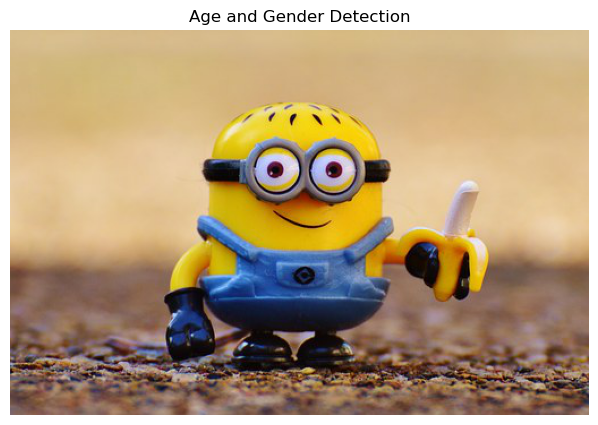

Saved static image result to output\minion_detected.jpg


In [12]:
# === Static Image Test ===
IMAGE_ADDRESS = os.path.join("images", "minion.jpg")
image = cv2.imread(IMAGE_ADDRESS)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
result = detect_face_age_gender(image)

plt.figure(figsize=(10, 5))
plt.imshow(result)
plt.axis("off")
plt.title("Age and Gender Detection")
plt.show()

# Save the result to output directory
result_bgr = cv2.cvtColor(result, cv2.COLOR_RGB2BGR)
output_image_path = os.path.join(OUTPUT_DIR, "minion_detected.jpg")
cv2.imwrite(output_image_path, result_bgr)
print(f"Saved static image result to {output_image_path}")

No face detected


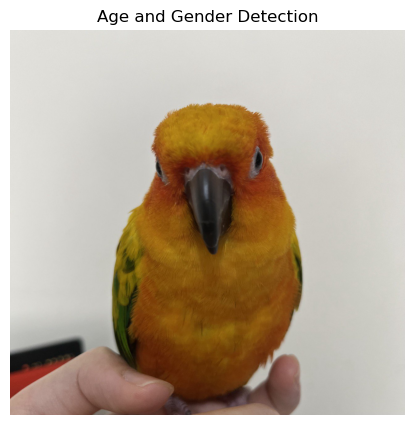

Saved static image result to output\sunny_detected.jpg


In [13]:
# === Static Image Test ===
IMAGE_ADDRESS = os.path.join("images", "sunny.jpg")
image = cv2.imread(IMAGE_ADDRESS)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
result = detect_face_age_gender(image)

plt.figure(figsize=(10, 5))
plt.imshow(result)
plt.axis("off")
plt.title("Age and Gender Detection")
plt.show()

# Save the result to output directory
result_bgr = cv2.cvtColor(result, cv2.COLOR_RGB2BGR)
output_image_path = os.path.join(OUTPUT_DIR, "sunny_detected.jpg")
cv2.imwrite(output_image_path, result_bgr)
print(f"Saved static image result to {output_image_path}")

## Age Detection Using Webcam

The webcam stream is used for real-time detection. Frames are resized and processed, and predictions are drawn and shown live, along with calculated FPS.

In [14]:
# === Webcam Mode ===

# Constants for camera settings
CAMERA_DEVICE_ID = 0  # ID for the camera device
IMAGE_WIDTH = 800  # Width of the captured image
IMAGE_HEIGHT = 600  # Height of the captured image
fps = 0  # Initial Frames Per Second (FPS) value
padding = 20  # Padding around the detected face for cropping

if __name__ == "__main__":  # Ensures that the code only runs when executed directly
    try:
        cap = cv2.VideoCapture(0)
        while True:
            start_time = time.time()
            hasFrame, frame = cap.read()
            # if not hasFrame:
            #     break
            if not hasFrame:
                cv2.waitKey()  # Wait indefinitely for a key event
                break  # Exit the loop if no frame is captured
            frame = cv2.resize(frame, (IMAGE_WIDTH, IMAGE_HEIGHT))
            resultImg = detect_face_age_gender(frame)
            # Display the frame with FPS overlay
            cv2.imshow("Detecting age and gender", visualize_fps(resultImg, fps))
            end_time = time.time()
            seconds = end_time - start_time
            fps = 1.0 / seconds
            # Break the loop if the 'Esc' key (ASCII 27) is pressed
            if cv2.waitKey(33) == 27:
                break
    except Exception as e:  # Handle exceptions that may occur
        print(e)  # Print the exception message
    finally:
        cv2.destroyAllWindows()  # Close all OpenCV windows
        cap.release()  # Release the camera resource


## Age and Gender Detection Using Video

This section processes all .mp4, .avi, and .mov files in the videos/ folder. It performs the same analysis per frame as in webcam mode, including FPS calculation and frame duration enforcement to maintain frame rate.

In [15]:
# === Video Mode ===
video_directory = "videos"
video_files = [f for f in os.listdir(video_directory) if f.endswith((".mp4", ".avi", ".mov"))]

IMAGE_WIDTH = 1000
IMAGE_HEIGHT = 600
FRAME_RATE = 30
DURATION = 1 / FRAME_RATE
fps = 0

try:
    for video_file in video_files:
        video_path = os.path.join(video_directory, video_file)
        print(f"Processing: {video_file}")
        cap = cv2.VideoCapture(video_path)

        # Define output video path and writer
        output_video_path = os.path.join(OUTPUT_DIR, f"detected_{video_file}")
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        out = cv2.VideoWriter(output_video_path, fourcc, FRAME_RATE, (IMAGE_WIDTH, IMAGE_HEIGHT))

        while True:
            start_time = time.time()
            hasFrame, frame = cap.read()
            if not hasFrame:
                break

            frame = cv2.resize(frame, (IMAGE_WIDTH, IMAGE_HEIGHT))
            resultImg = detect_face_age_gender(frame)
            resultImg = visualize_fps(resultImg, fps)

            # Show the frame (optional)
            cv2.imshow("Detecting age and gender", resultImg)

            # Write to output video
            out.write(resultImg)

            end_time = time.time()
            seconds = end_time - start_time
            if seconds < DURATION:
                time.sleep(DURATION - seconds)
            fps = 1.0 / max(time.time() - start_time, 1e-6)

            if cv2.waitKey(33) == 27:  # ESC key
                break

        cap.release()
        out.release()
        cv2.destroyAllWindows()
        print(f"Saved processed video to {output_video_path}")

except Exception as e:
    print(f"Error: {e}")
finally:
    cv2.destroyAllWindows()


Processing: Einstein_1.mp4
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
Saved processed video to output\detected_Einstein_1.mp4
Processing: Einstein_2.mp4
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No face detected
No fac

Since the associated model is capable of recognizing faces at the best angle, i.e., from the front, the skewed face, which is visible in most cases in the video frames, leads to non-detection, however, in most cases we have obtained reasonable results.

This project highlights how deep learning models can be integrated with OpenCV pipelines for efficient real-time facial attribute estimation. Though not always accurate (especially in low light or non-human images), the system performs reliably on real faces and is suitable for use in educational, security, or demographic analytics applications.